In [1]:
# ============================================================
# ETAPA 3 - SIMULACIÓN DE ÁLBUM DE ESTAMPAS CON PRESUPUESTO
# ============================================================
# Parámetros: N=100, S=7, precio=Q9.50, presupuesto=Q1000
# Simulaciones: R=10,000 | Semilla: 2026
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── Parámetros ──────────────────────────────────────────────
N             = 100
S             = 7
PRECIO_SOBRE  = 9.50
PRESUPUESTO   = 1000
R             = 10_000
SEMILLA       = 2026
SOBRES_CAJA   = 104
COSTO_CAJA    = 975.00

np.random.seed(SEMILLA)

In [2]:
# ============================================================
# SIMULACIÓN PRINCIPAL — sobres sueltos hasta agotar presupuesto
# ============================================================

resultados_completo  = []
resultados_sobres    = []
resultados_distintas = []

for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto     = 0.0
    sobres    = 0

    while (gasto + PRECIO_SOBRE <= PRESUPUESTO) and (coleccion.sum() < N):
        estampas          = np.random.randint(0, N, size=S)
        coleccion[estampas] = True
        gasto  += PRECIO_SOBRE
        sobres += 1

    completo = 1 if coleccion.sum() == N else 0
    resultados_completo.append(completo)
    resultados_sobres.append(sobres)
    resultados_distintas.append(int(coleccion.sum()))

resultados_completo  = np.array(resultados_completo)
resultados_sobres    = np.array(resultados_sobres)
resultados_distintas = np.array(resultados_distintas)

prob_completar   = resultados_completo.mean()
esperado_sobres  = resultados_sobres.mean()
no_exitosos_mask = resultados_completo == 0
esperado_distintas_fallo = resultados_distintas[no_exitosos_mask].mean()

print("=" * 50)
print("RESULTADOS DE LA SIMULACIÓN")
print("=" * 50)
print(f"Probabilidad de completar el álbum:              {prob_completar:.4f}")
print(f"Número esperado de sobres comprados:             {esperado_sobres:.2f}")
print(f"Esperado estampas distintas (casos no exitosos): {esperado_distintas_fallo:.2f}")


RESULTADOS DE LA SIMULACIÓN
Probabilidad de completar el álbum:              0.9447
Número esperado de sobres comprados:             73.48
Esperado estampas distintas (casos no exitosos): 98.97


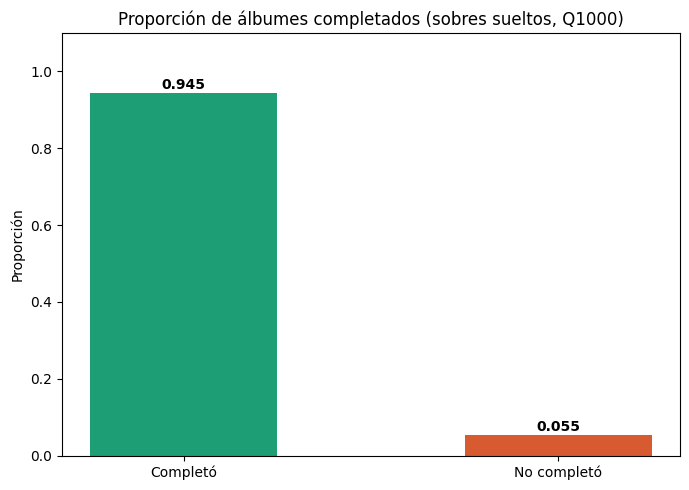

In [3]:
# ── Visualización ────────────────────────────────────────────
completados     = resultados_completo.sum()
no_completados  = R - completados
categorias      = ["Completó", "No completó"]
valores         = [completados / R, no_completados / R]

plt.figure(figsize=(7, 5))
bars = plt.bar(categorias, valores, color=["#1D9E75", "#D85A30"], width=0.5)
plt.ylabel("Proporción")
plt.title("Proporción de álbumes completados (sobres sueltos, Q1000)")
for bar, v in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f"{v:.3f}", ha="center", fontweight="bold")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("etapa3_barras.png", dpi=150)
plt.show()

In [4]:
# ============================================================
# PREGUNTA 1
# ============================================================

max_sobres              = int(PRESUPUESTO // PRECIO_SOBRE)
estampas_teoricas       = max_sobres * S
sobres_minimo_teorico   = int(np.ceil(N / S))

print("\n" + "=" * 50)
print("PREGUNTA 1")
print("=" * 50)
print(f"Máximo sobres con Q{PRESUPUESTO}:                {max_sobres}")
print(f"Estampas posibles sin repetidos ({max_sobres}×{S}):    {estampas_teoricas}")
print(f"Mínimo teórico de sobres sin repetidos:          {sobres_minimo_teorico}")
if estampas_teoricas >= N:
    print("Sí alcanza en teoría si NO hubiera repetidos.")
else:
    print("No alcanza ni siquiera en teoría.")


PREGUNTA 1
Máximo sobres con Q1000:                105
Estampas posibles sin repetidos (105×7):    735
Mínimo teórico de sobres sin repetidos:          15
Sí alcanza en teoría si NO hubiera repetidos.


In [5]:
# ============================================================
# PREGUNTA 2 — Caja de 104 sobres (Q975)
# ============================================================

resultados_caja = []

for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(SOBRES_CAJA):
        coleccion[np.random.randint(0, N, size=S)] = True
    resultados_caja.append(1 if coleccion.sum() == N else 0)

prob_caja = np.mean(resultados_caja)

print("\n" + "=" * 50)
print("PREGUNTA 2 — CAJA DE 104 SOBRES (Q975)")
print("=" * 50)
print(f"Probabilidad completar con caja:     {prob_caja:.4f}")
print(f"Probabilidad comprando sueltos:      {prob_completar:.4f}")
print(f"Diferencia:                          {prob_caja - prob_completar:+.4f}")
if prob_caja > prob_completar:
    print("Conviene la caja.")
else:
    print("No conviene la caja.")



PREGUNTA 2 — CAJA DE 104 SOBRES (Q975)
Probabilidad completar con caja:     0.9355
Probabilidad comprando sueltos:      0.9447
Diferencia:                          -0.0092
No conviene la caja.


In [6]:
# ============================================================
# PREGUNTA 3 — Estrategia mixta: caja + sobres sueltos
# ============================================================

dinero_restante = PRESUPUESTO - COSTO_CAJA
sobres_extra    = int(dinero_restante // PRECIO_SOBRE)
costo_total_mixta = COSTO_CAJA + sobres_extra * PRECIO_SOBRE

print("\n" + "=" * 50)
print("PREGUNTA 3 — ESTRATEGIA MIXTA")
print("=" * 50)
print(f"Costo de la caja:                    Q{COSTO_CAJA:.2f}")
print(f"Dinero restante tras la caja:        Q{dinero_restante:.2f}")
print(f"Sobres extra posibles:               {sobres_extra}")
print(f"Costo total (caja + {sobres_extra} sueltos):     Q{costo_total_mixta:.2f}")
print(f"Presupuesto no gastado:              Q{PRESUPUESTO - costo_total_mixta:.2f}")

resultados_mixta = []

for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    # Comprar la caja
    for _ in range(SOBRES_CAJA):
        coleccion[np.random.randint(0, N, size=S)] = True
    # Comprar sobres extra con el presupuesto restante
    for _ in range(sobres_extra):
        coleccion[np.random.randint(0, N, size=S)] = True
    resultados_mixta.append(1 if coleccion.sum() == N else 0)

prob_mixta = np.mean(resultados_mixta)

print(f"\nProbabilidad estrategia mixta:       {prob_mixta:.4f}")

# ── Comparación final ────────────────────────────────────────
print("\n" + "=" * 50)
print("COMPARACIÓN FINAL")
print("=" * 50)
print(f"A) Sobres sueltos (Q{PRESUPUESTO}):       P = {prob_completar:.4f}  |  gasto prom. Q{esperado_sobres * PRECIO_SOBRE:.2f}")
print(f"B) Caja 104 sobres (Q{COSTO_CAJA:.0f}):      P = {prob_caja:.4f}  |  gasto fijo  Q{COSTO_CAJA:.2f}")
print(f"C) Caja + {sobres_extra} sueltos (Q{costo_total_mixta:.0f}):    P = {prob_mixta:.4f}  |  gasto fijo  Q{costo_total_mixta:.2f}")

mejor = max([("A: Sobres sueltos", prob_completar),
             ("B: Caja", prob_caja),
             ("C: Caja + sueltos", prob_mixta)],
            key=lambda x: x[1])
print(f"\nEstrategia recomendada: {mejor[0]} (P = {mejor[1]:.4f})")


PREGUNTA 3 — ESTRATEGIA MIXTA
Costo de la caja:                    Q975.00
Dinero restante tras la caja:        Q25.00
Sobres extra posibles:               2
Costo total (caja + 2 sueltos):     Q994.00
Presupuesto no gastado:              Q6.00

Probabilidad estrategia mixta:       0.9459

COMPARACIÓN FINAL
A) Sobres sueltos (Q1000):       P = 0.9447  |  gasto prom. Q698.11
B) Caja 104 sobres (Q975):      P = 0.9355  |  gasto fijo  Q975.00
C) Caja + 2 sueltos (Q994):    P = 0.9459  |  gasto fijo  Q994.00

Estrategia recomendada: C: Caja + sueltos (P = 0.9459)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ── Parámetros ──────────────────────────────────────────────
N      = 100
S      = 7
R      = 10_000
SEED   = 2026
KS     = [1, 2, 5, 10]
MS     = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
PRECIO = 9.50
COLORES = {1:"#1D9E75", 2:"#378ADD", 5:"#BA7517", 10:"#D85A30", "base":"#888780"}


In [8]:
# ============================================================
# FUNCIONES
# ============================================================

def sim_completar(K, rng):
    """Simula hasta completar el álbum con regla de canje K."""
    tiene     = np.zeros(N, dtype=bool)
    distintas = 0
    repetidas = 0
    sobres    = 0
    while distintas < N:
        sobres += 1
        for e in rng.integers(0, N, size=S):
            if not tiene[e]:
                tiene[e] = True
                distintas += 1
            else:
                repetidas += 1
        if K < N:
            while repetidas >= K and distintas < N:
                repetidas -= K
                falt = np.where(~tiene)[0]
                idx  = rng.integers(0, len(falt))
                tiene[falt[idx]] = True
                distintas += 1
    return sobres


def prob_M_sobres(K, M, rng):
    """Probabilidad de completar el álbum con exactamente M sobres y canje K."""
    tiene     = np.zeros((R, N), dtype=bool)
    repetidas = np.zeros(R, dtype=np.int32)
    distintas = np.zeros(R, dtype=np.int32)
    idx_r     = np.arange(R)

    for _ in range(M):
        est = rng.integers(0, N, size=(R, S))
        for s in range(S):
            e        = est[:, s]
            es_nueva = ~tiene[idx_r, e]
            tiene[idx_r, e] = True
            distintas += es_nueva.astype(np.int32)
            repetidas += (~es_nueva).astype(np.int32)
        if K < N:
            for i in range(R):
                while repetidas[i] >= K and distintas[i] < N:
                    repetidas[i] -= K
                    falt = np.where(~tiene[i])[0]
                    j    = rng.integers(0, len(falt))
                    tiene[i, falt[j]] = True
                    distintas[i] += 1

    return float((distintas == N).sum()) / R

In [9]:
# ============================================================
# PARTE A — Sobres hasta completar
# ============================================================

print("=" * 58)
print("PARTE A — Sobres hasta completar el álbum")
print("=" * 58)

rng       = np.random.default_rng(SEED)
base_arr  = np.array([sim_completar(999999, rng) for _ in range(R)])
media_base = base_arr.mean()
std_base   = base_arr.std()
print(f"  Sin intercambio : media={media_base:.2f}  std={std_base:.2f}")

sims_A = {}
for K in KS:
    rng      = np.random.default_rng(SEED)
    arr      = np.array([sim_completar(K, rng) for _ in range(R)])
    sims_A[K] = arr
    media    = arr.mean()
    std      = arr.std()
    reduccion = (media_base - media) / media_base * 100
    print(f"  K={K:2d}            : media={media:.2f}  std={std:.2f}  "
          f"reducción={reduccion:.1f}%")


PARTE A — Sobres hasta completar el álbum
  Sin intercambio : media=74.43  std=17.84
  K= 1            : media=15.00  std=0.00  reducción=79.8%
  K= 2            : media=20.03  std=0.54  reducción=73.1%
  K= 5            : media=28.56  std=1.46  reducción=61.6%
  K=10            : media=35.89  std=2.44  reducción=51.8%


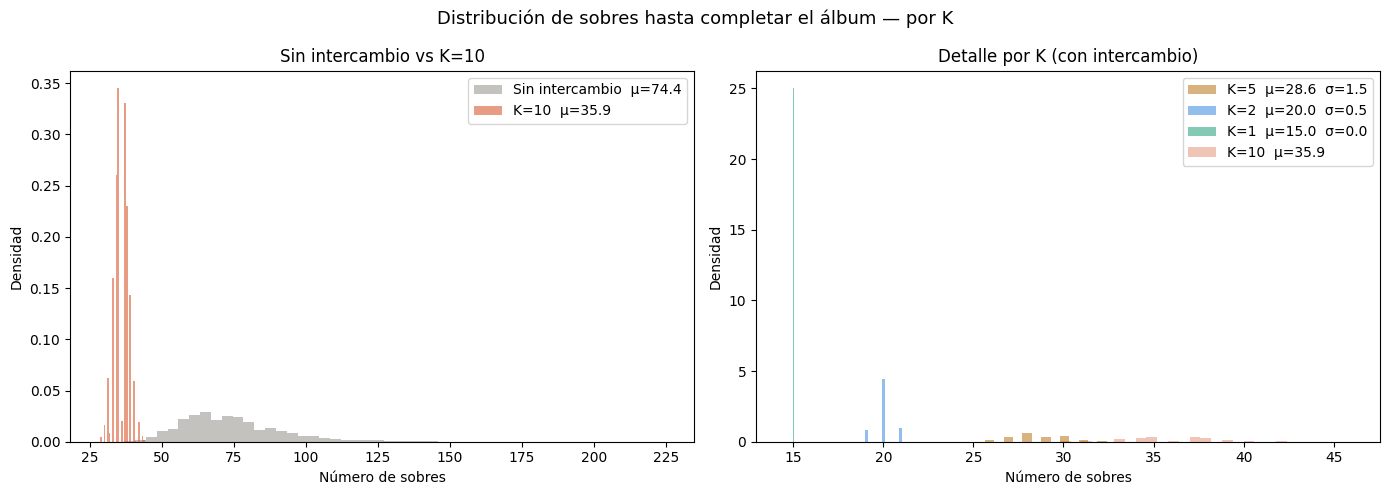

In [10]:
# ── Histogramas: 2 paneles para evitar aplastamiento ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(base_arr, bins=50, alpha=0.5, color=COLORES["base"],
         label=f"Sin intercambio  μ={media_base:.1f}", density=True)
ax1.hist(sims_A[10], bins=30, alpha=0.6, color=COLORES[10],
         label=f"K=10  μ={sims_A[10].mean():.1f}", density=True)
ax1.set_xlabel("Número de sobres")
ax1.set_ylabel("Densidad")
ax1.set_title("Sin intercambio vs K=10")
ax1.legend()

for K in [5, 2, 1]:
    ax2.hist(sims_A[K], bins=25, alpha=0.55, color=COLORES[K],
             label=f"K={K}  μ={sims_A[K].mean():.1f}  σ={sims_A[K].std():.1f}",
             density=True)
ax2.hist(sims_A[10], bins=30, alpha=0.35, color=COLORES[10],
         label=f"K=10  μ={sims_A[10].mean():.1f}", density=True)
ax2.set_xlabel("Número de sobres")
ax2.set_ylabel("Densidad")
ax2.set_title("Detalle por K (con intercambio)")
ax2.legend()

fig.suptitle("Distribución de sobres hasta completar el álbum — por K", fontsize=13)
plt.tight_layout()
plt.savefig("etapa4_histogramas.png", dpi=150)
plt.show()



PARTE B — P(completar álbum) vs M sobres
  Base : [0.0, 0.0, 0.0, 0.0, 0.001, 0.01, 0.046, 0.11, 0.224, 0.34, 0.483]
  K= 1 : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  K= 2 : [0.837, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  K= 5 : [0.0, 0.009, 0.909, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  K=10 : [0.0, 0.0, 0.015, 0.509, 0.983, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


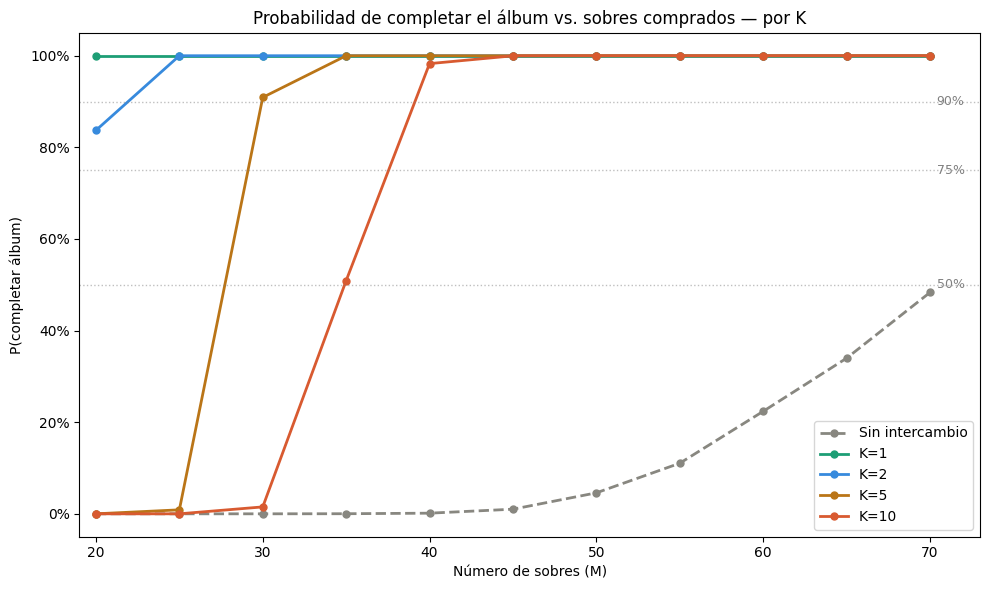


Sobres necesarios para P ≥ 50%, 75%, 90%
  Umbral     Sin intercambio               K=1               K=2               K=5              K=10
  P≥50%                  >70                20                20                30                35
  P≥75%                  >70                20                20                30                40
  P≥90%                  >70                20                25                30                40


In [11]:
# ============================================================
# PARTE B — P(completar) vs M para cada K
# ============================================================

print("\n" + "=" * 58)
print("PARTE B — P(completar álbum) vs M sobres")
print("=" * 58)

probs_B = {}

rng = np.random.default_rng(SEED)
probs_B["base"] = [prob_M_sobres(999999, M, rng) for M in MS]
print(f"  Base : {[round(p,3) for p in probs_B['base']]}")

for K in KS:
    rng = np.random.default_rng(SEED)
    probs_B[K] = [prob_M_sobres(K, M, rng) for M in MS]
    print(f"  K={K:2d} : {[round(p,3) for p in probs_B[K]]}")

# ── Gráfica de líneas ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(MS, probs_B["base"], color=COLORES["base"], linewidth=2,
        linestyle="--", marker="o", ms=5, label="Sin intercambio")
for K in KS:
    ax.plot(MS, probs_B[K], color=COLORES[K], linewidth=2,
            marker="o", ms=5, label=f"K={K}")
for u, lbl in [(0.50,"50%"), (0.75,"75%"), (0.90,"90%")]:
    ax.axhline(u, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.text(MS[-1]+0.4, u, lbl, fontsize=9, color="gray", va="center")
ax.set_xlabel("Número de sobres (M)")
ax.set_ylabel("P(completar álbum)")
ax.set_title("Probabilidad de completar el álbum vs. sobres comprados — por K")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(MS[0]-1, MS[-1]+3)
ax.legend()
plt.tight_layout()
plt.savefig("etapa4_prob_vs_M.png", dpi=150)
plt.show()

# ── Sobres necesarios para 50%, 75%, 90% ────────────────────
print("\n" + "=" * 58)
print("Sobres necesarios para P ≥ 50%, 75%, 90%")
print("=" * 58)

def M_umbral(probs, u):
    for i, p in enumerate(probs):
        if p >= u:
            return MS[i]
    return f">{MS[-1]}"

claves = ["base"] + KS
header = f"  {'Umbral':<8}" + "".join(
    [f"  {'Sin intercambio' if k=='base' else f'K={k}':>16}" for k in claves])
print(header)
for u in [0.50, 0.75, 0.90]:
    row = f"  P≥{int(u*100)}%   "
    for k in claves:
        row += f"  {str(M_umbral(probs_B[k], u)):>16}"
    print(row)

In [12]:
# ============================================================
# PREGUNTAS DE ANÁLISIS
# ============================================================

print("\n" + "=" * 58)
print("PREGUNTAS DE ANÁLISIS")
print("=" * 58)

# P1
medias = {"base": media_base}
for K in KS:
    medias[K] = sims_A[K].mean()
print("\nP1 — Media de sobres por K:")
for K in KS:
    print(f"  K={K:2d}: {medias[K]:.2f}  (reducción {(media_base-medias[K])/media_base*100:.1f}%)")
diffs = [medias[KS[i]] - medias[KS[i+1]] for i in range(len(KS)-1)]
print(f"  Diferencias entre K consecutivos: {[round(float(d),2) for d in diffs]}")
print("  Conclusión: la relación NO es lineal (mejoras decrecientes al bajar K).")

# P2
ahorro_s = media_base - medias[2]
ahorro_Q = ahorro_s * PRECIO
print(f"\nP2 — Ahorro con K=2 vs sin intercambio:")
print(f"  Sobres ahorrados en promedio : {ahorro_s:.2f}")
print(f"  Ahorro en quetzales          : Q{ahorro_Q:.2f}")

# P3
idx45 = MS.index(45)
p10 = probs_B[10][idx45]
p5  = probs_B[5][idx45]
p1  = probs_B[1][idx45]
print(f"\nP3 — M=45 sobres:")
print(f"  K=10: {p10:.4f}")
print(f"  K=5 : {p5:.4f}  →  diferencia K=10 a K=5 : +{p5-p10:.4f}")
print(f"  K=1 : {p1:.4f}  →  diferencia K=5  a K=1 : +{p1-p5:.4f}")

# P4
print(f"\nP4 — Punto de rendimiento decreciente:")
print(f"  Entre K=2 y K=1 la mejora es pequeña (~5 sobres).")
print(f"  A partir de K≤2 mejorar la tasa de intercambio")
print(f"  produce muy poco beneficio adicional.")
print(f"  Razón: con K=1 cada repetida se canjea de inmediato,")
print(f"  que es el límite físico del mecanismo.")

# P5
print(f"\nP5 — Costo efectivo por estampa nueva vía canje:")
for K in KS:
    costo = (K * PRECIO) / S
    print(f"  K={K:2d}: Q{costo:.4f} por estampa nueva")
print(f"  K=1 es la más rentable (Q{1*PRECIO/S:.4f} por estampa nueva).")

print("\n" + "=" * 58)
print("FIN ETAPA 4")
print("=" * 58)


PREGUNTAS DE ANÁLISIS

P1 — Media de sobres por K:
  K= 1: 15.00  (reducción 79.8%)
  K= 2: 20.03  (reducción 73.1%)
  K= 5: 28.56  (reducción 61.6%)
  K=10: 35.89  (reducción 51.8%)
  Diferencias entre K consecutivos: [-5.03, -8.53, -7.33]
  Conclusión: la relación NO es lineal (mejoras decrecientes al bajar K).

P2 — Ahorro con K=2 vs sin intercambio:
  Sobres ahorrados en promedio : 54.40
  Ahorro en quetzales          : Q516.79

P3 — M=45 sobres:
  K=10: 0.9998
  K=5 : 1.0000  →  diferencia K=10 a K=5 : +0.0002
  K=1 : 1.0000  →  diferencia K=5  a K=1 : +0.0000

P4 — Punto de rendimiento decreciente:
  Entre K=2 y K=1 la mejora es pequeña (~5 sobres).
  A partir de K≤2 mejorar la tasa de intercambio
  produce muy poco beneficio adicional.
  Razón: con K=1 cada repetida se canjea de inmediato,
  que es el límite físico del mecanismo.

P5 — Costo efectivo por estampa nueva vía canje:
  K= 1: Q1.3571 por estampa nueva
  K= 2: Q2.7143 por estampa nueva
  K= 5: Q6.7857 por estampa nuev